In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from ta.momentum import RSIIndicator
from tradeModul.analysis import show_basic_info,evaluate_model, plot_predictions_and_table
from tradeModul.csv_loader import load_data, save_data

# Увеличить максимальное количество отображаемых столбцов
pd.set_option('display.max_columns', None)  # или число, например 50
# Увеличить ширину строки вывода
pd.set_option('display.width', 1000)
# Увеличить максимальное количество символов в ячейке
pd.set_option('display.max_colwidth', None)

FILE_PATH = 'btc_4h_history.csv'

In [2]:
# !pip install python-binance

In [3]:
from binance.client import Client
# Создание клиента
client = Client()

# Загрузка исторических данных 
symbol = "BTCUSDT"
interval = Client.KLINE_INTERVAL_4HOUR
start_time = "1 Jan 2017"
start_time = "1 Jan 2023"
end_time = None    # Конечная дата

klines = client.get_historical_klines(symbol, interval, start_time, end_time)

# Преобразование данных в DataFrame
columns = [
    "Open time", "Open", "High", "Low", "Close", "Volume",
    "Close time", "Quote asset volume", "Number of trades",
    "Taker buy base asset volume", "Taker buy quote asset volume", "Ignore"
]
df = pd.DataFrame(klines, columns=columns)

if end_time is None:
    print("Удаляем последнюю (незавершённую) свечу")
    df = df.iloc[:-1].copy()  
    
# # Преобразование времени в читаемый формат
df["Open_datetime"] = pd.to_datetime(df["Open time"], unit="ms").dt.strftime("%Y-%m-%d %H:%M")
df["Close_datetime"] = pd.to_datetime(df["Close time"], unit="ms").dt.strftime("%Y-%m-%d %H:%M")

df["Open_datetime_local"] = pd.to_datetime(df["Open time"], unit="ms", utc=True).dt.tz_convert("Europe/Moscow").dt.strftime("%Y-%m-%d %H:%M")  # ← ваш часовой пояс
df["Close_datetime_local"] = pd.to_datetime(df["Close time"], unit="ms", utc=True).dt.tz_convert("Europe/Moscow").dt.strftime("%Y-%m-%d %H:%M")  # ← ваш часовой пояс

# Сохранение данных в CSV
df.to_csv(FILE_PATH, index=False)

print("Размер данных: " + str(len(df)))
print(df[["Open_datetime","Close_datetime", "Open", "Close", "Open_datetime_local", "Close_datetime_local"]].head(3))

print("Последние 3 свечи:")
print(df[["Open_datetime","Close_datetime", "Open", "Close", "Open_datetime_local", "Close_datetime_local"]].tail(3))

Удаляем последнюю (незавершённую) свечу
Размер данных: 6056
      Open_datetime    Close_datetime            Open           Close Open_datetime_local Close_datetime_local
0  2023-01-01 00:00  2023-01-01 03:59  16541.77000000  16533.04000000    2023-01-01 03:00     2023-01-01 06:59
1  2023-01-01 04:00  2023-01-01 07:59  16533.04000000  16526.19000000    2023-01-01 07:00     2023-01-01 10:59
2  2023-01-01 08:00  2023-01-01 11:59  16525.70000000  16556.66000000    2023-01-01 11:00     2023-01-01 14:59
Последние 3 свечи:
         Open_datetime    Close_datetime             Open            Close Open_datetime_local Close_datetime_local
6053  2025-10-05 20:00  2025-10-05 23:59  122591.80000000  123482.31000000    2025-10-05 23:00     2025-10-06 02:59
6054  2025-10-06 00:00  2025-10-06 03:59  123482.32000000  123839.09000000    2025-10-06 03:00     2025-10-06 06:59
6055  2025-10-06 04:00  2025-10-06 07:59  123839.09000000  123390.47000000    2025-10-06 07:00     2025-10-06 10:59


In [4]:
df = load_data(FILE_PATH, 100000)

show_basic_info(df)

Данные успешно загружены из 'btc_4h_history.csv'. Форма: (6056, 16)

ФОРМА И ТИПЫ ДАННЫХ
Форма данных (строк, столбцов): (6056, 16)
Имена столбцов: ['Open time', 'Open', 'High', 'Low', 'Close', 'Volume', 'Close time', 'Quote asset volume', 'Number of trades', 'Taker buy base asset volume', 'Taker buy quote asset volume', 'Ignore', 'Open_datetime', 'Close_datetime', 'Open_datetime_local', 'Close_datetime_local']
Типы данных по столбцам:
Open time                         int64
Open                            float64
High                            float64
Low                             float64
Close                           float64
Volume                          float64
Close time                        int64
Quote asset volume              float64
Number of trades                  int64
Taker buy base asset volume     float64
Taker buy quote asset volume    float64
Ignore                            int64
Open_datetime                    object
Close_datetime                   object


In [5]:
# !pip install finta

In [6]:
# Параметры
WINDOW = 8
H = 1  # прогноз на 1 шаг вперёд (4 часа)
TEST_LAST_N = 20

df.set_index('Open_datetime_local', inplace=True)

# Расчёт индикаторов EMA50 и RSI(14)
df['EMA14'] = df['Close'].ewm(span=14).mean()
df['EMA50'] = df['Close'].ewm(span=50).mean()
rsi_indicator = RSIIndicator(close=df['Close'], window=14)
df['RSI14'] = rsi_indicator.rsi()
# Удаление строк с NaN
df.dropna(inplace=True)

# Подготовка признаков
features = ['Open', 'High', 'Low', 'Close', 'Volume','EMA14', 'EMA50', 'RSI14', 'Number of trades']
data = df[features].values
target = df['Close'].values

# Создание окон
X, y = [], []
for i in range(WINDOW, len(data) - H + 1):
    X.append(data[i - WINDOW:i])  # окно из WINDOW свечей
    y.append(target[i + H - 1])  # close через H шагов

X = np.array(X)
y = np.array(y)

# Преобразуем X в форму 2D (n_samples, n_features), где n_features = WINDOW * n_indicators
n_samples, n_timesteps, n_features = X.shape
X_flat = X.reshape(n_samples, n_timesteps * n_features)

# Разделение на обучающую и тестовую выборки
X_train = X_flat[:-TEST_LAST_N]
X_test = X_flat[-TEST_LAST_N:]
y_train = y[:-TEST_LAST_N]
y_test = y[-TEST_LAST_N:]

# Получаем соответствующие даты для тестовых примеров
test_dates = df.index[WINDOW + H - 1:][len(y_train):]  # даты для тестовых значений

 ОЦЕНКА МОДЕЛИ
 MAE: 1932.94
 RMSE: 2207.55
 MAPE: 1.57%
 R²: -2.2161
 SMAPE: 1.59%
 Directional Accuracy: 57.89%

 Подробный отчет по тестовым данным:
        Datetime    Actual   Predicted     Error  Abs Error  Pct Error (%)
2025-10-03 03:00 120225.89 120178.4407   47.4493    47.4493       0.039467
2025-10-03 07:00 119640.21 120269.8978 -629.6878   629.6878       0.526318
2025-10-03 11:00 120334.50 120049.7588  284.7412   284.7412       0.236625
2025-10-03 15:00 122258.05 120239.2199 2018.8301  2018.8301       1.651286
2025-10-03 19:00 122660.99 121089.9636 1571.0264  1571.0264       1.280787
2025-10-03 23:00 122232.00 121414.8228  817.1772   817.1772       0.668546
2025-10-04 03:00 122243.99 120951.3920 1292.5980  1292.5980       1.057392
2025-10-04 07:00 122324.08 121109.4187 1214.6613  1214.6613       0.992986
2025-10-04 11:00 121973.26 120901.8500 1071.4100  1071.4100       0.878397
2025-10-04 15:00 121791.31 120131.6056 1659.7044  1659.7044       1.362745
2025-10-04 19:00 121959

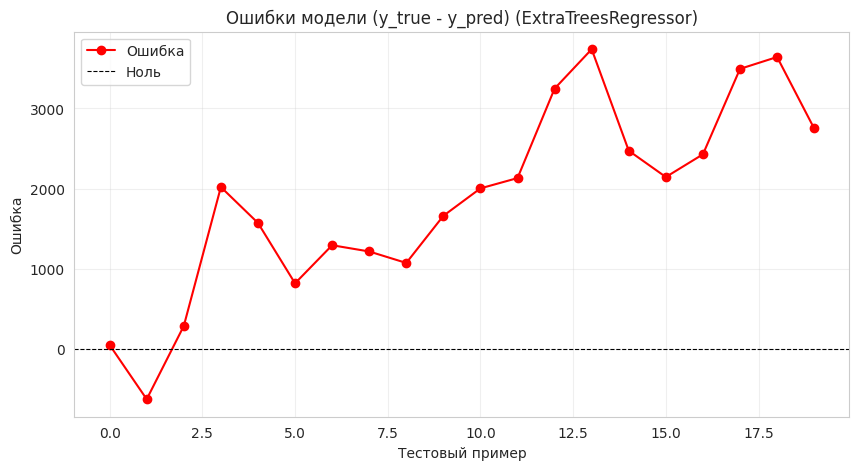

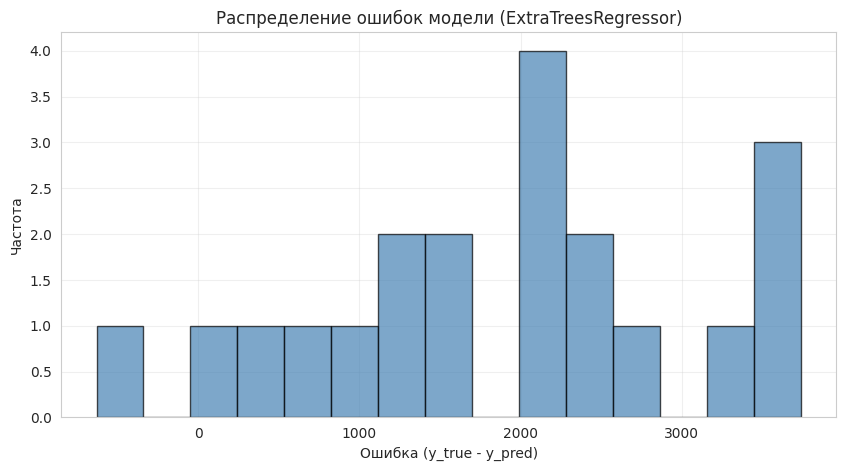


 Статистика ошибок:
Средняя ошибка: 1869.97
Медианная ошибка: 2010.67
Максимальная ошибка: 3739.49
95% квантиль ошибок: 3647.08
 Прогноз vs Факт

 Прогноз vs Факт:
        Datetime    Actual   Predicted
2025-10-03 03:00 120225.89 120178.4407
2025-10-03 07:00 119640.21 120269.8978
2025-10-03 11:00 120334.50 120049.7588
2025-10-03 15:00 122258.05 120239.2199
2025-10-03 19:00 122660.99 121089.9636
2025-10-03 23:00 122232.00 121414.8228
2025-10-04 03:00 122243.99 120951.3920
2025-10-04 07:00 122324.08 121109.4187
2025-10-04 11:00 121973.26 120901.8500
2025-10-04 15:00 121791.31 120131.6056
2025-10-04 19:00 121959.25 119956.7386
2025-10-04 23:00 122391.00 120260.0776
2025-10-05 03:00 123776.22 120528.1542
2025-10-05 07:00 124713.63 120974.1358
2025-10-05 11:00 123464.64 120992.5664
2025-10-05 15:00 122803.17 120659.1374
2025-10-05 19:00 122591.79 120164.2087
2025-10-05 23:00 123482.31 119988.1199
2025-10-06 03:00 123839.09 120196.8773
2025-10-06 07:00 123390.47 120640.0663


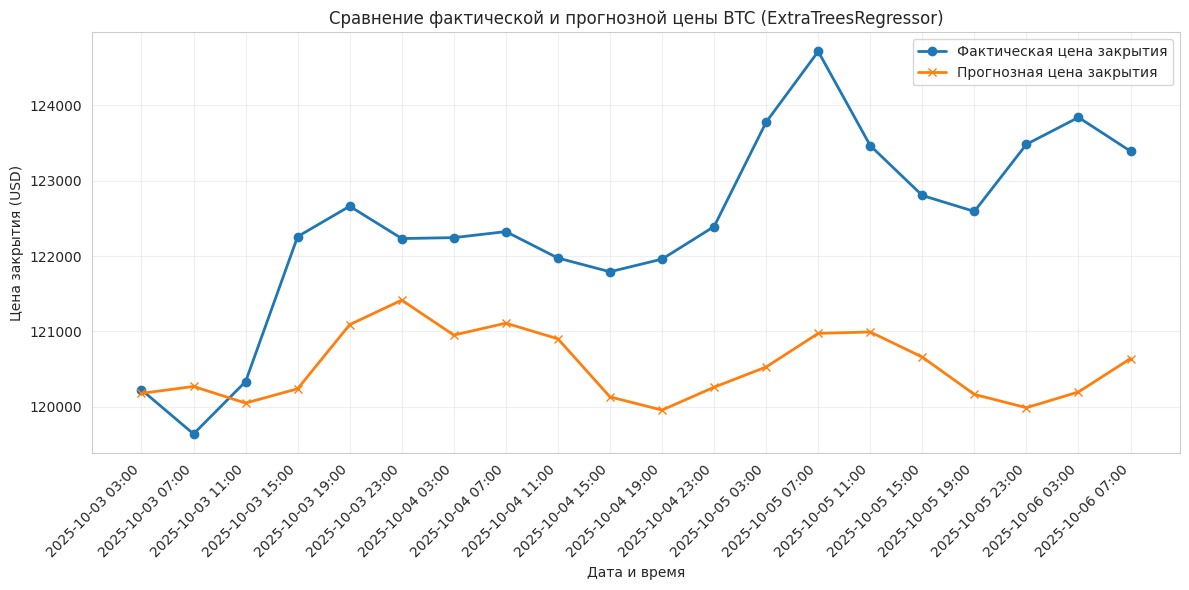

Построение графика важности параметров с подписями...


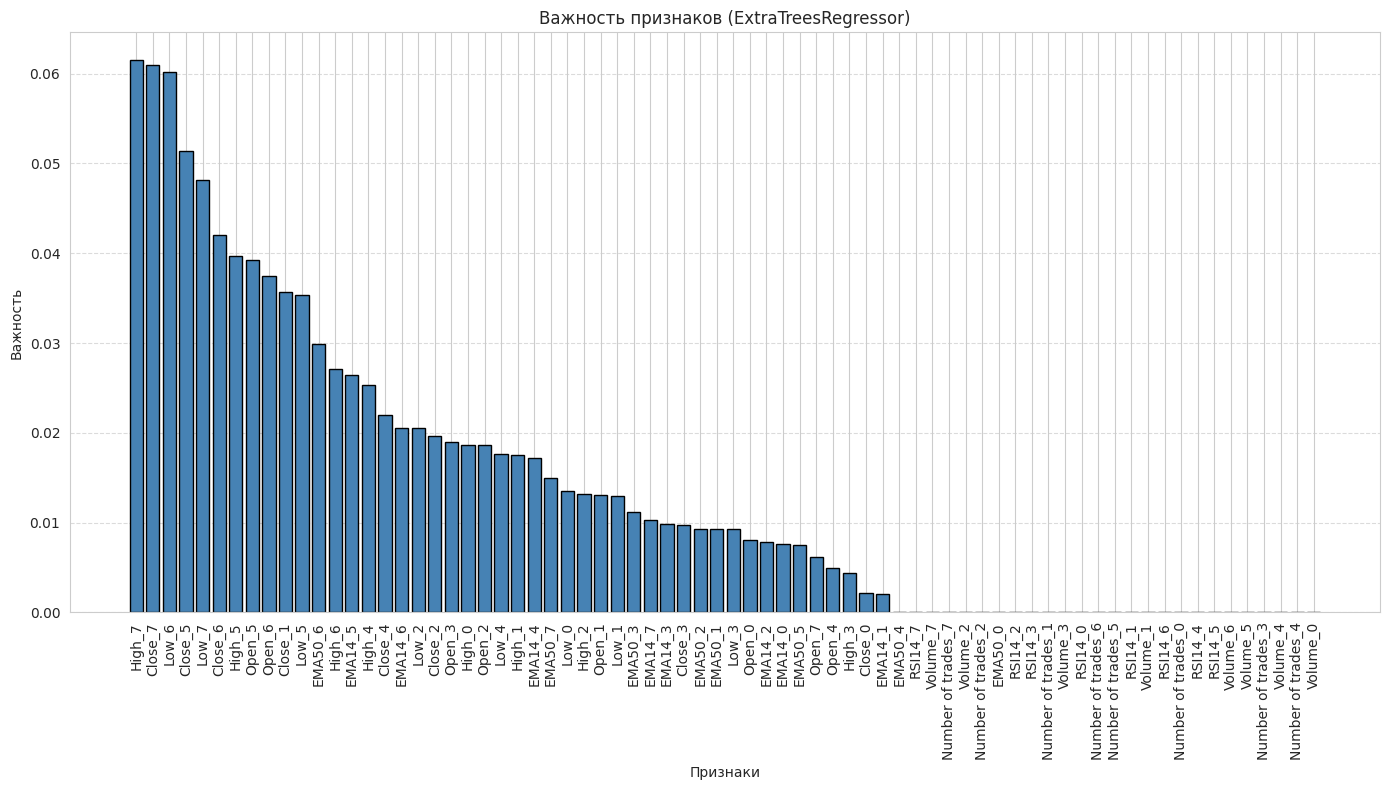

In [7]:
model = ExtraTreesRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

evaluate_model(y_test, y_pred, test_dates, title_suffix="(ExtraTreesRegressor)", show_plots=True)
plot_predictions_and_table(y_test, y_pred, test_dates=test_dates, title_suffix="(ExtraTreesRegressor)", show_table=True, show_plot=True)

# Построение графика важности параметров с подписями
print("Построение графика важности параметров с подписями...")

importances = model.feature_importances_
indices = np.argsort(importances)[::-1]  

# Создаем список имен признаков
feature_names = []
for i in range(WINDOW):  # Для каждой свечи в окне
    for col in features:  # Для каждого признака
        feature_names.append(f"{col}_{i}")

sorted_feature_names = [feature_names[i] for i in indices]

plt.figure(figsize=(14, 8))
plt.title("Важность признаков (ExtraTreesRegressor)")
plt.bar(range(len(importances)), importances[indices], align="center", color='steelblue', edgecolor='black')
plt.xticks(range(len(importances)), sorted_feature_names, rotation=90, fontsize=10)
plt.xlabel("Признаки")
plt.ylabel("Важность")
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

 ОЦЕНКА МОДЕЛИ
 MAE: 1188.91
 RMSE: 1394.55
 MAPE: 0.97%
 R²: -0.2834
 SMAPE: 0.97%
 Directional Accuracy: 52.63%

 Подробный отчет по тестовым данным:
        Datetime    Actual   Predicted     Error  Abs Error  Pct Error (%)
2025-10-03 03:00 120225.89 120098.6894  127.2006   127.2006       0.105801
2025-10-03 07:00 119640.21 120312.1540 -671.9440   671.9440       0.561637
2025-10-03 11:00 120334.50 119874.6622  459.8378   459.8378       0.382133
2025-10-03 15:00 122258.05 120151.8592 2106.1908  2106.1908       1.722742
2025-10-03 19:00 122660.99 121708.3702  952.6198   952.6198       0.776628
2025-10-03 23:00 122232.00 122003.9554  228.0446   228.0446       0.186567
2025-10-04 03:00 122243.99 121503.9293  740.0607   740.0607       0.605396
2025-10-04 07:00 122324.08 121513.8467  810.2333   810.2333       0.662366
2025-10-04 11:00 121973.26 121253.3799  719.8801   719.8801       0.590195
2025-10-04 15:00 121791.31 121075.0750  716.2350   716.2350       0.588084
2025-10-04 19:00 121959

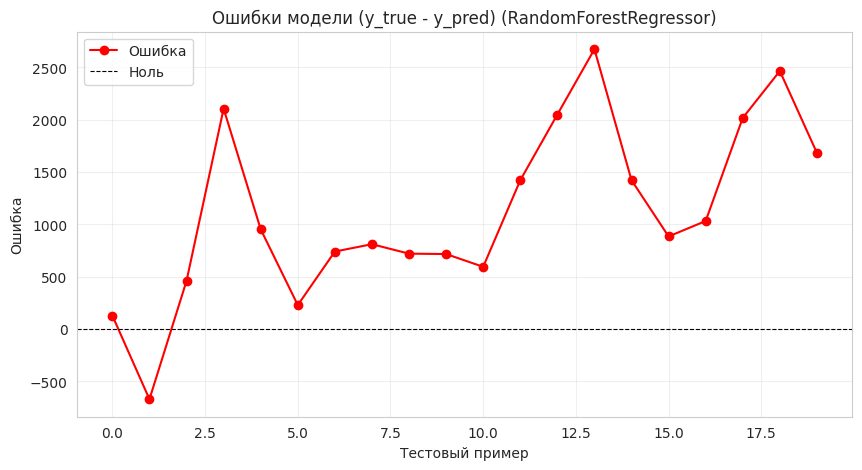

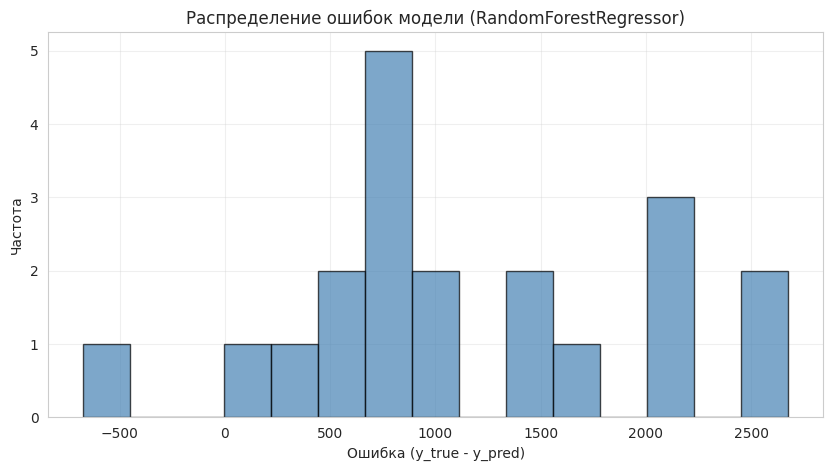


 Статистика ошибок:
Средняя ошибка: 1121.71
Медианная ошибка: 918.53
Максимальная ошибка: 2674.48
95% квантиль ошибок: 2476.58
 Прогноз vs Факт

 Прогноз vs Факт:
        Datetime    Actual   Predicted
2025-10-03 03:00 120225.89 120098.6894
2025-10-03 07:00 119640.21 120312.1540
2025-10-03 11:00 120334.50 119874.6622
2025-10-03 15:00 122258.05 120151.8592
2025-10-03 19:00 122660.99 121708.3702
2025-10-03 23:00 122232.00 122003.9554
2025-10-04 03:00 122243.99 121503.9293
2025-10-04 07:00 122324.08 121513.8467
2025-10-04 11:00 121973.26 121253.3799
2025-10-04 15:00 121791.31 121075.0750
2025-10-04 19:00 121959.25 121365.1742
2025-10-04 23:00 122391.00 120969.3107
2025-10-05 03:00 123776.22 121726.2507
2025-10-05 07:00 124713.63 122039.1460
2025-10-05 11:00 123464.64 122042.5644
2025-10-05 15:00 122803.17 121918.7390
2025-10-05 19:00 122591.79 121559.7661
2025-10-05 23:00 123482.31 121464.3677
2025-10-06 03:00 123839.09 121372.9238
2025-10-06 07:00 123390.47 121707.4713


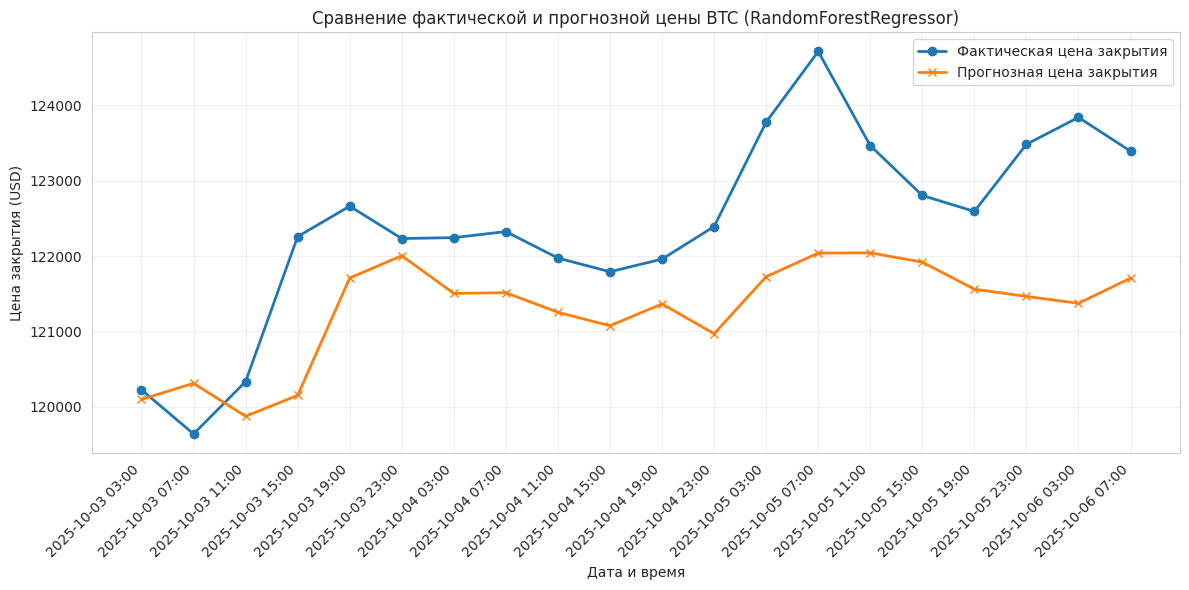

,Datetime,Actual,Predicted
0,2025-10-03 03:00,120225.89,120098.6894
1,2025-10-03 07:00,119640.21,120312.1540
2,2025-10-03 11:00,120334.50,119874.6622
3,2025-10-03 15:00,122258.05,120151.8592
4,2025-10-03 19:00,122660.99,121708.3702
5,2025-10-03 23:00,122232.00,122003.9554
6,2025-10-04 03:00,122243.99,121503.9293
7,2025-10-04 07:00,122324.08,121513.8467
8,2025-10-04 11:00,121973.26,121253.3799
9,2025-10-04 15:00,121791.31,121075.0750


In [8]:
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

evaluate_model(y_test, y_pred, test_dates, title_suffix="(RandomForestRegressor)", show_plots=True)
plot_predictions_and_table(y_test, y_pred, test_dates=test_dates, title_suffix="(RandomForestRegressor)", show_table=True, show_plot=True)

In [9]:
# !pip install xgboost

 ОЦЕНКА МОДЕЛИ
 MAE: 1351.77
 RMSE: 1549.24
 MAPE: 1.10%
 R²: -0.5840
 SMAPE: 1.11%
 Directional Accuracy: 73.68%

 Подробный отчет по тестовым данным:
        Datetime    Actual     Predicted       Error   Abs Error  Pct Error (%)
2025-10-03 03:00 120225.89 120316.186234  -90.296234   90.296234       0.075105
2025-10-03 07:00 119640.21 119851.769403 -211.559403  211.559403       0.176830
2025-10-03 11:00 120334.50 119628.807321  705.692679  705.692679       0.586443
2025-10-03 15:00 122258.05 119682.444847 2575.605153 2575.605153       2.106696
2025-10-03 19:00 122660.99 121430.150295 1230.839705 1230.839705       1.003448
2025-10-03 23:00 122232.00 121320.385285  911.614715  911.614715       0.745807
2025-10-04 03:00 122243.99 121291.893098  952.096902  952.096902       0.778850
2025-10-04 07:00 122324.08 121170.375182 1153.704818 1153.704818       0.943154
2025-10-04 11:00 121973.26 121021.913828  951.346172  951.346172       0.779963
2025-10-04 15:00 121791.31 120862.264305  929.04

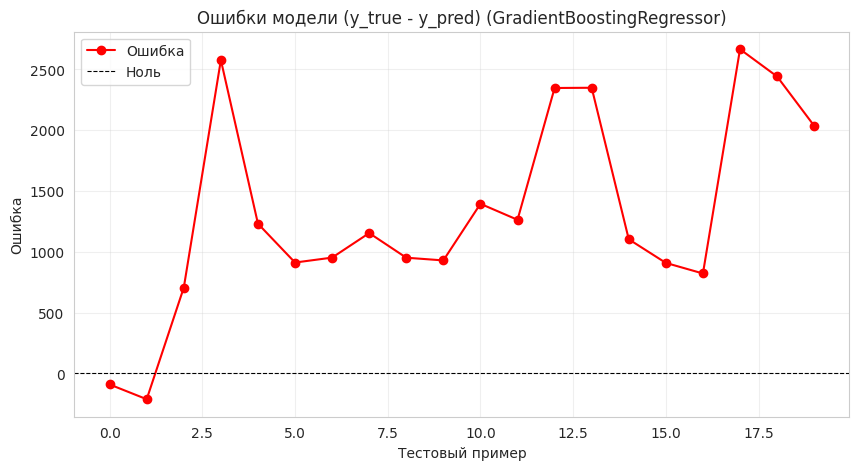

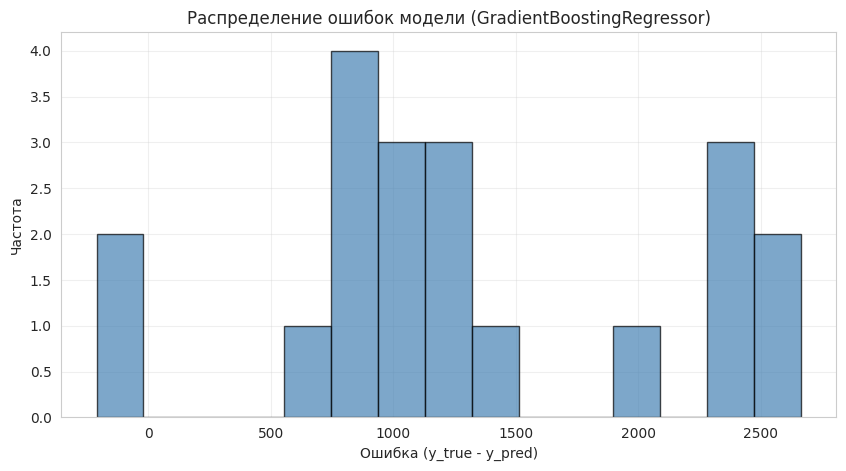


 Статистика ошибок:
Средняя ошибка: 1321.58
Медианная ошибка: 1128.20
Максимальная ошибка: 2664.46
95% квантиль ошибок: 2580.05
 Прогноз vs Факт

 Прогноз vs Факт:
        Datetime    Actual     Predicted
2025-10-03 03:00 120225.89 120316.186234
2025-10-03 07:00 119640.21 119851.769403
2025-10-03 11:00 120334.50 119628.807321
2025-10-03 15:00 122258.05 119682.444847
2025-10-03 19:00 122660.99 121430.150295
2025-10-03 23:00 122232.00 121320.385285
2025-10-04 03:00 122243.99 121291.893098
2025-10-04 07:00 122324.08 121170.375182
2025-10-04 11:00 121973.26 121021.913828
2025-10-04 15:00 121791.31 120862.264305
2025-10-04 19:00 121959.25 120564.993121
2025-10-04 23:00 122391.00 121128.147917
2025-10-05 03:00 123776.22 121430.354210
2025-10-05 07:00 124713.63 122365.831087
2025-10-05 11:00 123464.64 122361.951373
2025-10-05 15:00 122803.17 121894.598313
2025-10-05 19:00 122591.79 121770.168248
2025-10-05 23:00 123482.31 120817.847845
2025-10-06 03:00 123839.09 121398.678906
2025-10-06 07:0

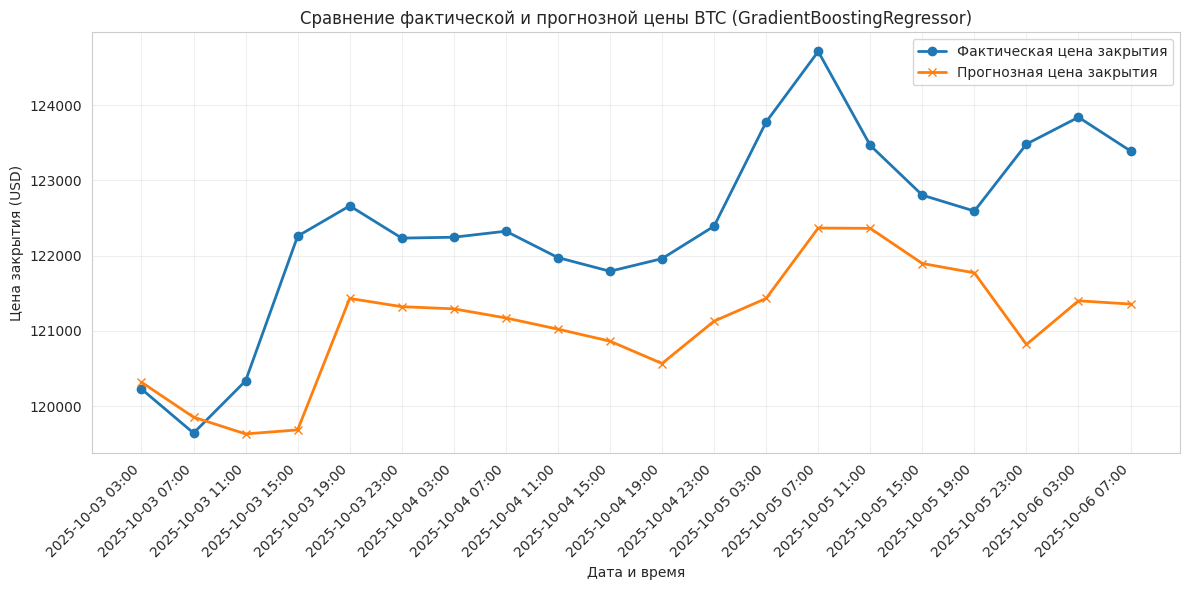

,Datetime,Actual,Predicted
0,2025-10-03 03:00,120225.89,120316.186234
1,2025-10-03 07:00,119640.21,119851.769403
2,2025-10-03 11:00,120334.50,119628.807321
3,2025-10-03 15:00,122258.05,119682.444847
4,2025-10-03 19:00,122660.99,121430.150295
5,2025-10-03 23:00,122232.00,121320.385285
6,2025-10-04 03:00,122243.99,121291.893098
7,2025-10-04 07:00,122324.08,121170.375182
8,2025-10-04 11:00,121973.26,121021.913828
9,2025-10-04 15:00,121791.31,120862.264305


In [10]:
from sklearn.ensemble import GradientBoostingRegressor

model = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

evaluate_model(y_test, y_pred, test_dates, title_suffix="(GradientBoostingRegressor)", show_plots=True)
plot_predictions_and_table(y_test, y_pred, test_dates=test_dates, title_suffix="(GradientBoostingRegressor)", show_table=True, show_plot=True)

 ОЦЕНКА МОДЕЛИ
 MAE: 1859.96
 RMSE: 2031.92
 MAPE: 1.51%
 R²: -1.7247
 SMAPE: 1.53%
 Directional Accuracy: 52.63%

 Подробный отчет по тестовым данным:
        Datetime    Actual     Predicted       Error   Abs Error  Pct Error (%)
2025-10-03 03:00 120225.89 120501.436631 -275.546631  275.546631       0.229191
2025-10-03 07:00 119640.21 120576.066917 -935.856917  935.856917       0.782226
2025-10-03 11:00 120334.50 119540.558915  793.941085  793.941085       0.659778
2025-10-03 15:00 122258.05 120455.004408 1803.045592 1803.045592       1.474787
2025-10-03 19:00 122660.99 120528.155130 2132.834870 2132.834870       1.738805
2025-10-03 23:00 122232.00 120703.845124 1528.154876 1528.154876       1.250209
2025-10-04 03:00 122243.99 120580.667688 1663.322312 1663.322312       1.360658
2025-10-04 07:00 122324.08 120536.884842 1787.195158 1787.195158       1.461033
2025-10-04 11:00 121973.26 120609.110082 1364.149918 1364.149918       1.118401
2025-10-04 15:00 121791.31 120248.164291 1543.14

/home/gr/.local/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


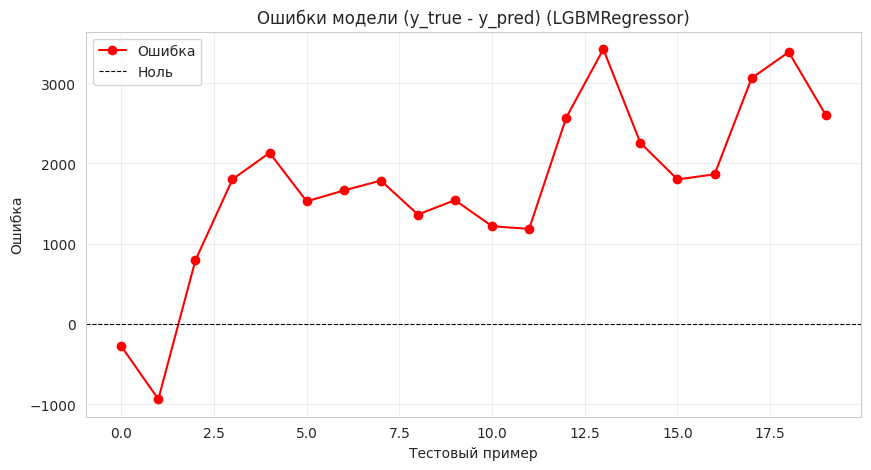

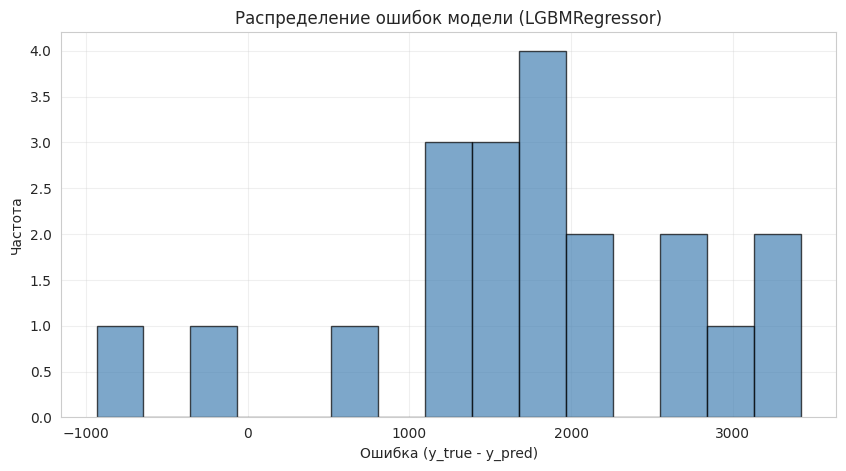


 Статистика ошибок:
Средняя ошибка: 1738.82
Медианная ошибка: 1794.24
Максимальная ошибка: 3422.62
95% квантиль ошибок: 3388.76
 Прогноз vs Факт

 Прогноз vs Факт:
        Datetime    Actual     Predicted
2025-10-03 03:00 120225.89 120501.436631
2025-10-03 07:00 119640.21 120576.066917
2025-10-03 11:00 120334.50 119540.558915
2025-10-03 15:00 122258.05 120455.004408
2025-10-03 19:00 122660.99 120528.155130
2025-10-03 23:00 122232.00 120703.845124
2025-10-04 03:00 122243.99 120580.667688
2025-10-04 07:00 122324.08 120536.884842
2025-10-04 11:00 121973.26 120609.110082
2025-10-04 15:00 121791.31 120248.164291
2025-10-04 19:00 121959.25 120741.281631
2025-10-04 23:00 122391.00 121205.448315
2025-10-05 03:00 123776.22 121205.448315
2025-10-05 07:00 124713.63 121291.007875
2025-10-05 11:00 123464.64 121208.384167
2025-10-05 15:00 122803.17 121001.879387
2025-10-05 19:00 122591.79 120727.275205
2025-10-05 23:00 123482.31 120419.724739
2025-10-06 03:00 123839.09 120452.110518
2025-10-06 07:0

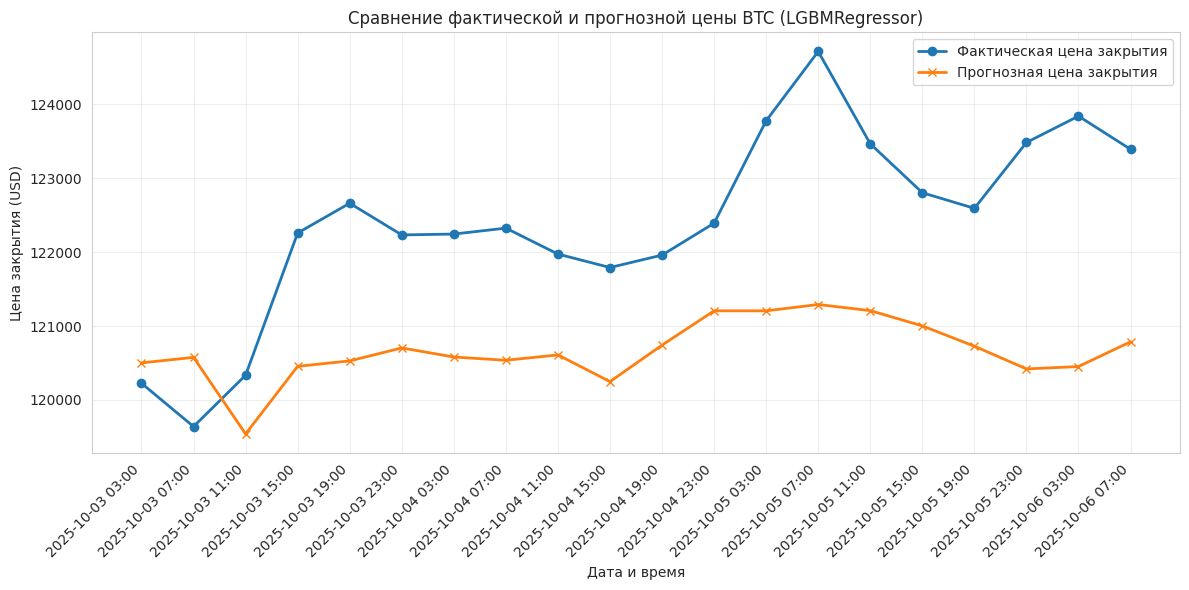

,Datetime,Actual,Predicted
0,2025-10-03 03:00,120225.89,120501.436631
1,2025-10-03 07:00,119640.21,120576.066917
2,2025-10-03 11:00,120334.50,119540.558915
3,2025-10-03 15:00,122258.05,120455.004408
4,2025-10-03 19:00,122660.99,120528.155130
5,2025-10-03 23:00,122232.00,120703.845124
6,2025-10-04 03:00,122243.99,120580.667688
7,2025-10-04 07:00,122324.08,120536.884842
8,2025-10-04 11:00,121973.26,120609.110082
9,2025-10-04 15:00,121791.31,120248.164291


In [11]:
from lightgbm import LGBMRegressor

model = LGBMRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42,
    verbose=-1  # отключаем логи
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

evaluate_model(y_test, y_pred, test_dates, title_suffix="(LGBMRegressor)", show_plots=True)
plot_predictions_and_table(y_test, y_pred, test_dates=test_dates, title_suffix="(LGBMRegressor)", show_table=True, show_plot=True)

2025-10-06 12:39:20.396338: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-06 12:39:20.401996: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-06 12:39:20.410943: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759743560.426503   22821 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759743560.430966   22821 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1759743560.443262   22821 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linkin

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
 ОЦЕНКА МОДЕЛИ
 MAE: 4274.95
 RMSE: 4361.09
 MAPE: 3.50%
 R²: -11.5516
 SMAPE: 3.44%
 Directional Accuracy: 36.84%

 Подробный отчет по тестовым данным:
        Datetime    Actual     Predicted        Error   Abs Error  Pct Error (%)
2025-10-03 03:00 120225.89 125202.843750 -4976.953750 4976.953750       4.139669
2025-10-03 07:00 119640.21 125500.531250 -5860.321250 5860.321250       4.898287
2025-10-03 11:00 120334.50 125439.515625 -5105.015625 5105.015625       4.242354
2025-10-03 15:00 122258.05 125372.250000 -3114.200000 3114.200000       2.547235
2025-10-03 19:00 122660.99 125852.093750 -3191.103750 3191.103750       2.601564
2025-10-03 23:00 122232.00 126566.093750 -4334.093750 4334.093750       3.545793
2025-10-04 03:00 122243.99 126678.718750 -4434.728750 4434.728750       3.627768
2025-10-04 07:00 122324.08 126703.234375 -4379.154375 4379.154375       3.579961
2025-10-04 11:00 121973.26 126819.335938 -4846.075938 4846.075938       3.973064

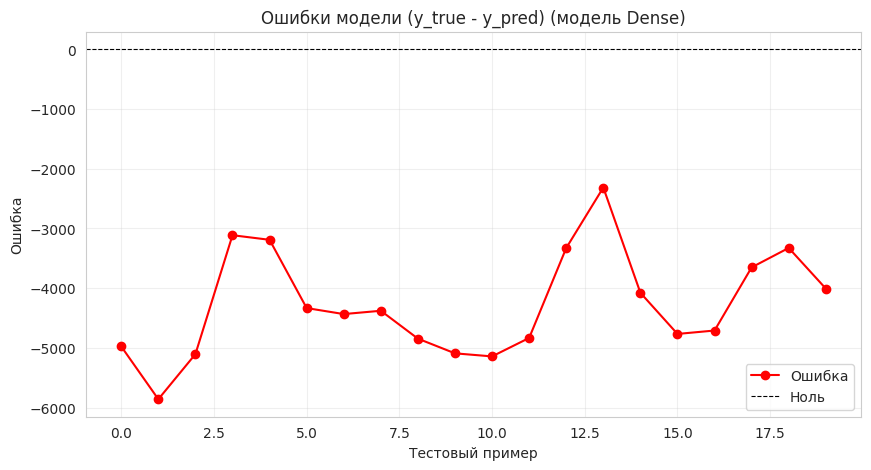

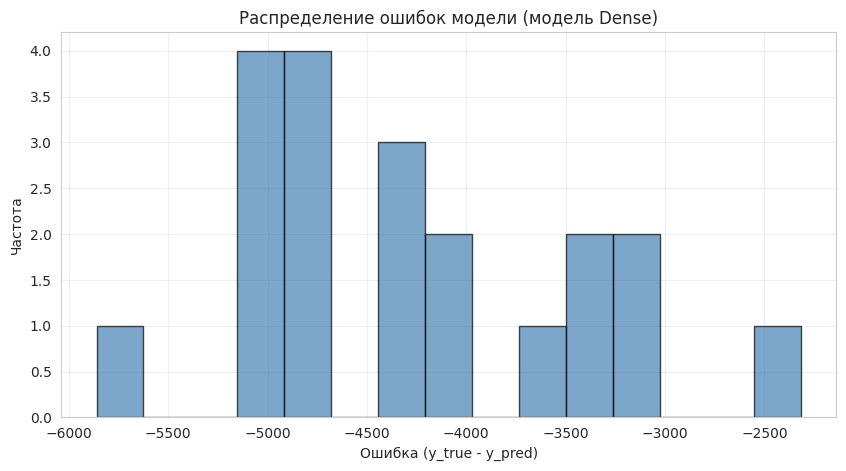


 Статистика ошибок:
Средняя ошибка: -4274.95
Медианная ошибка: -4406.94
Максимальная ошибка: 5860.32
95% квантиль ошибок: 5179.23
 Прогноз vs Факт

 Прогноз vs Факт:
        Datetime    Actual     Predicted
2025-10-03 03:00 120225.89 125202.843750
2025-10-03 07:00 119640.21 125500.531250
2025-10-03 11:00 120334.50 125439.515625
2025-10-03 15:00 122258.05 125372.250000
2025-10-03 19:00 122660.99 125852.093750
2025-10-03 23:00 122232.00 126566.093750
2025-10-04 03:00 122243.99 126678.718750
2025-10-04 07:00 122324.08 126703.234375
2025-10-04 11:00 121973.26 126819.335938
2025-10-04 15:00 121791.31 126883.375000
2025-10-04 19:00 121959.25 127102.632812
2025-10-04 23:00 122391.00 127225.390625
2025-10-05 03:00 123776.22 127104.726562
2025-10-05 07:00 124713.63 127029.351562
2025-10-05 11:00 123464.64 127542.734375
2025-10-05 15:00 122803.17 127570.453125
2025-10-05 19:00 122591.79 127301.882812
2025-10-05 23:00 123482.31 127134.960938
2025-10-06 03:00 123839.09 127166.500000
2025-10-06 07

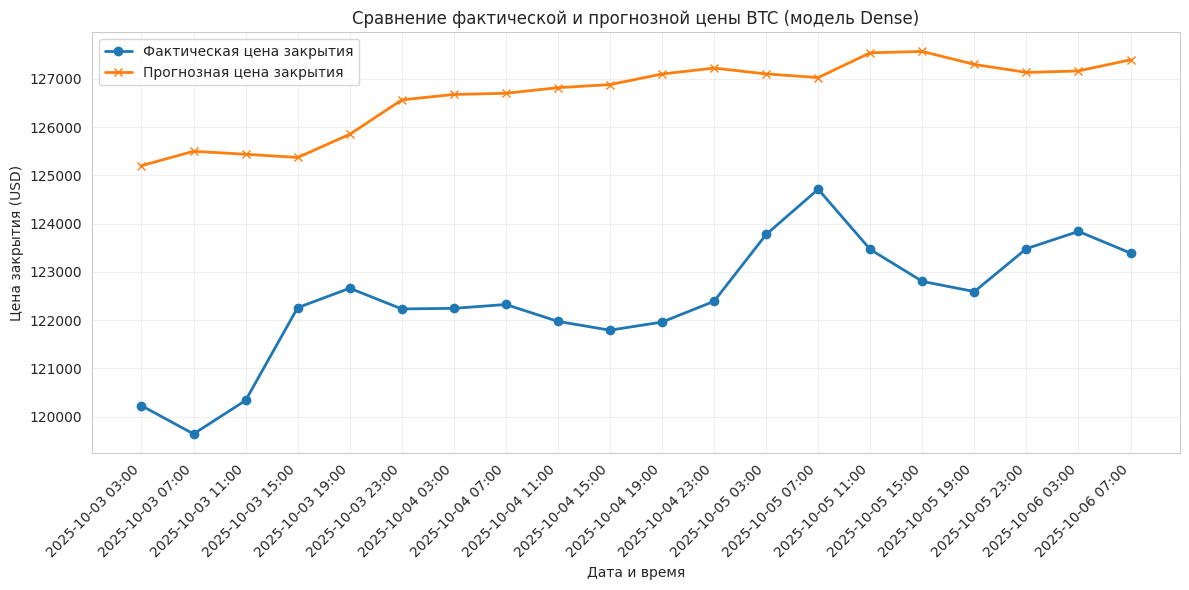

,Datetime,Actual,Predicted
0,2025-10-03 03:00,120225.89,125202.843750
1,2025-10-03 07:00,119640.21,125500.531250
2,2025-10-03 11:00,120334.50,125439.515625
3,2025-10-03 15:00,122258.05,125372.250000
4,2025-10-03 19:00,122660.99,125852.093750
5,2025-10-03 23:00,122232.00,126566.093750
6,2025-10-04 03:00,122243.99,126678.718750
7,2025-10-04 07:00,122324.08,126703.234375
8,2025-10-04 11:00,121973.26,126819.335938
9,2025-10-04 15:00,121791.31,126883.375000


In [12]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Масштабирование признаков
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_flat)

# Разделение на обучающую и тестовую выборки
X_train = X_scaled[:-TEST_LAST_N]
X_test = X_scaled[-TEST_LAST_N:]
y_train = y[:-TEST_LAST_N]
y_test = y[-TEST_LAST_N:]

# Получаем соответствующие даты для тестовых примеров
test_dates = df.index[WINDOW + H - 1:][len(y_train):]

model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)), 
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1)  
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=20, batch_size=32, verbose=0)

y_pred = model.predict(X_test).flatten()

evaluate_model(y_test, y_pred, test_dates, title_suffix="(модель Dense)", show_plots=True)
plot_predictions_and_table(y_test, y_pred, test_dates=test_dates, title_suffix="(модель Dense)", show_table=True, show_plot=True)

Обучение модели LSTM...


/home/gr/.local/lib/python3.10/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 155ms/step
 ОЦЕНКА МОДЕЛИ
 MAE: 2596.90
 RMSE: 2728.14
 MAPE: 2.12%
 R²: -3.9118
 SMAPE: 2.15%
 Directional Accuracy: 57.89%

 Подробный отчет по тестовым данным:
        Datetime    Actual     Predicted       Error   Abs Error  Pct Error (%)
2025-10-03 03:00 120225.89 116960.351562 3265.538437 3265.538437       2.716169
2025-10-03 07:00 119640.21 117558.289062 2081.920938 2081.920938       1.740152
2025-10-03 11:00 120334.50 118056.328125 2278.171875 2278.171875       1.893199
2025-10-03 15:00 122258.05 117892.109375 4365.940625 4365.940625       3.571086
2025-10-03 19:00 122660.99 118333.976562 4327.013438 4327.013438       3.527620
2025-10-03 23:00 122232.00 119326.773438 2905.226562 2905.226562       2.376813
2025-10-04 03:00 122243.99 119719.398438 2524.591563 2524.591563       2.065207
2025-10-04 07:00 122324.08 119486.750000 2837.330000 2837.330000       2.319519
2025-10-04 11:00 121973.26 119183.296875 2789.963125 2789.963125       2.287356
2025-10-0

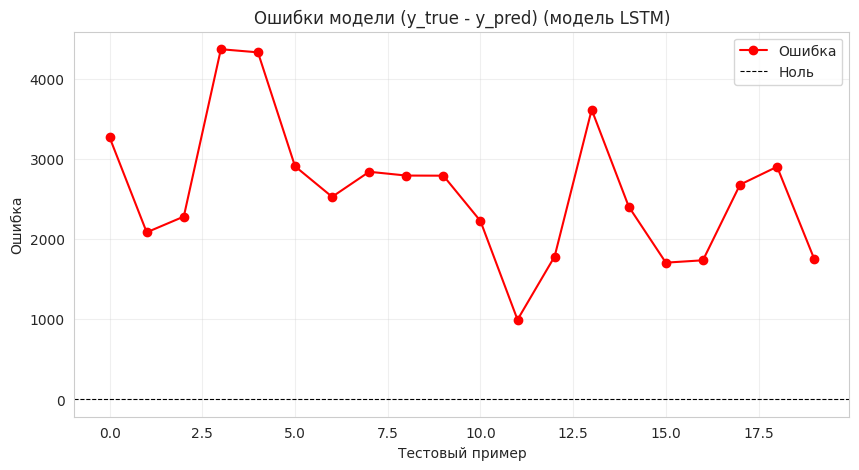

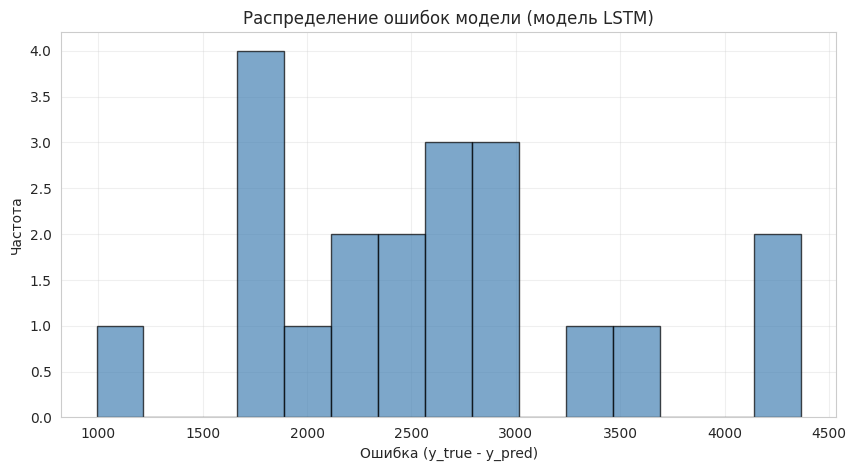


 Статистика ошибок:
Средняя ошибка: 2596.90
Медианная ошибка: 2600.49
Максимальная ошибка: 4365.94
95% квантиль ошибок: 4328.96
 Прогноз vs Факт

 Прогноз vs Факт:
        Datetime    Actual     Predicted
2025-10-03 03:00 120225.89 116960.351562
2025-10-03 07:00 119640.21 117558.289062
2025-10-03 11:00 120334.50 118056.328125
2025-10-03 15:00 122258.05 117892.109375
2025-10-03 19:00 122660.99 118333.976562
2025-10-03 23:00 122232.00 119326.773438
2025-10-04 03:00 122243.99 119719.398438
2025-10-04 07:00 122324.08 119486.750000
2025-10-04 11:00 121973.26 119183.296875
2025-10-04 15:00 121791.31 119002.875000
2025-10-04 19:00 121959.25 119735.906250
2025-10-04 23:00 122391.00 121399.039062
2025-10-05 03:00 123776.22 121996.070312
2025-10-05 07:00 124713.63 121101.570312
2025-10-05 11:00 123464.64 121062.578125
2025-10-05 15:00 122803.17 121099.570312
2025-10-05 19:00 122591.79 120858.742188
2025-10-05 23:00 123482.31 120805.929688
2025-10-06 03:00 123839.09 120939.039062
2025-10-06 07:0

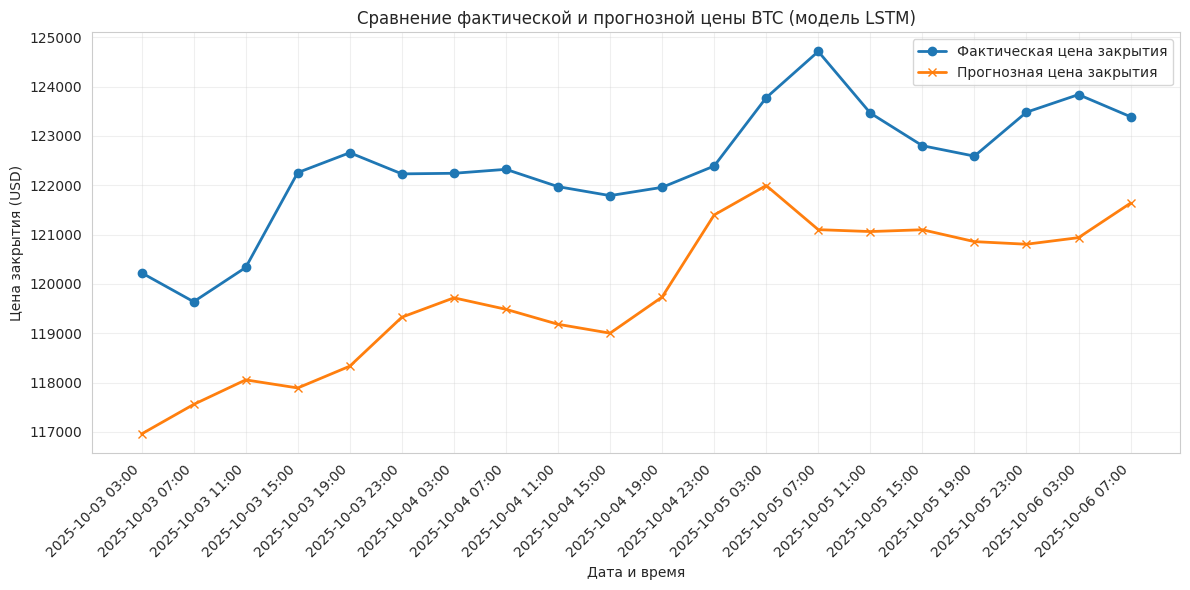

,Datetime,Actual,Predicted
0,2025-10-03 03:00,120225.89,116960.351562
1,2025-10-03 07:00,119640.21,117558.289062
2,2025-10-03 11:00,120334.50,118056.328125
3,2025-10-03 15:00,122258.05,117892.109375
4,2025-10-03 19:00,122660.99,118333.976562
5,2025-10-03 23:00,122232.00,119326.773438
6,2025-10-04 03:00,122243.99,119719.398438
7,2025-10-04 07:00,122324.08,119486.750000
8,2025-10-04 11:00,121973.26,119183.296875
9,2025-10-04 15:00,121791.31,119002.875000


In [13]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import MinMaxScaler

# Масштабирование признаков
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_flat)

# Возвращаем в 3D
X_3d = X_scaled.reshape(n_samples, n_timesteps, n_features)  # (n_samples, 5, 7)

# Разделение на обучающую и тестовую выборки
X_train = X_3d[:-TEST_LAST_N]
X_test = X_3d[-TEST_LAST_N:]
y_train = y[:-TEST_LAST_N]
y_test = y[-TEST_LAST_N:]

# Обучение модели LSTM
print("Обучение модели LSTM...")
model = Sequential([
    LSTM(50, activation='relu', input_shape=(WINDOW, n_features)),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
model.fit(X_train, y_train, epochs=15, batch_size=32, verbose=0)

y_pred = model.predict(X_test).flatten()

evaluate_model(y_test, y_pred, test_dates, title_suffix="(модель LSTM)", show_plots=True)
plot_predictions_and_table(y_test, y_pred, test_dates=test_dates, title_suffix="(модель LSTM)", show_table=True, show_plot=True)